# Analyze Model

Author: Purity Mukami 

In [1]:
import sys 
import pickle 
import pandas as pd

from pathlib import Path
from sklearn.metrics import classification_report, mean_squared_error, r2_score, balanced_accuracy_score, confusion_matrix
from scipy.stats import spearmanr

# Import project modules
PROJECT_ROOT = Path.cwd().parent.parent
sys.path.append(str(PROJECT_ROOT))
from config import paths 

from util.charts import * 

# Set to model that should be analyzed 
MODEL_NAME = 'KCHS'

# Output path for results 
OUT_PATH = paths.RESULTS / 'model_analysis' / f'{MODEL_NAME.lower()}'

#### Load validation data and models 

In [2]:

if MODEL_NAME == 'KCHS' : 
    print("Loading validation set for KCHS PMT...")
    validation_df = pd.read_csv(paths.PROCESSED_DATA / 'kchs_2021_validation.csv', low_memory=False, index_col='hhid')

elif MODEL_NAME == 'IBS' : 
    print("Loading validation set for IBS PMT...")
    validation_df = pd.read_csv(paths.PROCESSED_DATA / 'ibs_2015_validation.csv', low_memory=False, index_col='unique_id')

else : 
    raise Exception(f"{MODEL_NAME} invalid, select valid model name")

validation_df.head()

Loading validation set for KCHS PMT...


,Actual,Predicted,Actual_KES,Predicted_KES,Actual_Decile,Actual_Percentile,Predicted_Decile,Predicted_Percentile,log_error,strid,...,occupation_business_lady_man,occupation_casual_labour,occupation_farmer,occupation_housekeeper,occupation_housewife,occupation_private_sector_worker,occupation_public_sector_worker,actual_consumption_log,Actually_Poor,Predicted_Poor
hhid,,,,,,,,,,,,,,,,,,,,,
11472.0,9.843433,9.542311,18834.2680,13937.112583,10,97,10,92,-0.301123,11058.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.843433,False,False
16174.0,8.978422,8.836062,7930.1090,6877.856814,8,73,7,66,-0.142360,15626.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,8.978422,False,True
80.0,8.443020,8.511858,4642.5527,4973.395619,5,42,5,46,0.068838,74.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.443020,True,True
169.0,8.734915,8.770913,6216.2065,6444.053950,6,60,7,62,0.035998,158.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,8.734915,True,True
1005.0,9.490932,9.326391,13239.1230,11230.532121,10,92,9,87,-0.164540,964.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,9.490932,False,False


(<Figure size 2000x1300 with 1 Axes>,
 <Axes: title={'left': 'Predicted vs. Actual Consumption'}, xlabel='Actual (KES)', ylabel='Predicted (KES)'>)

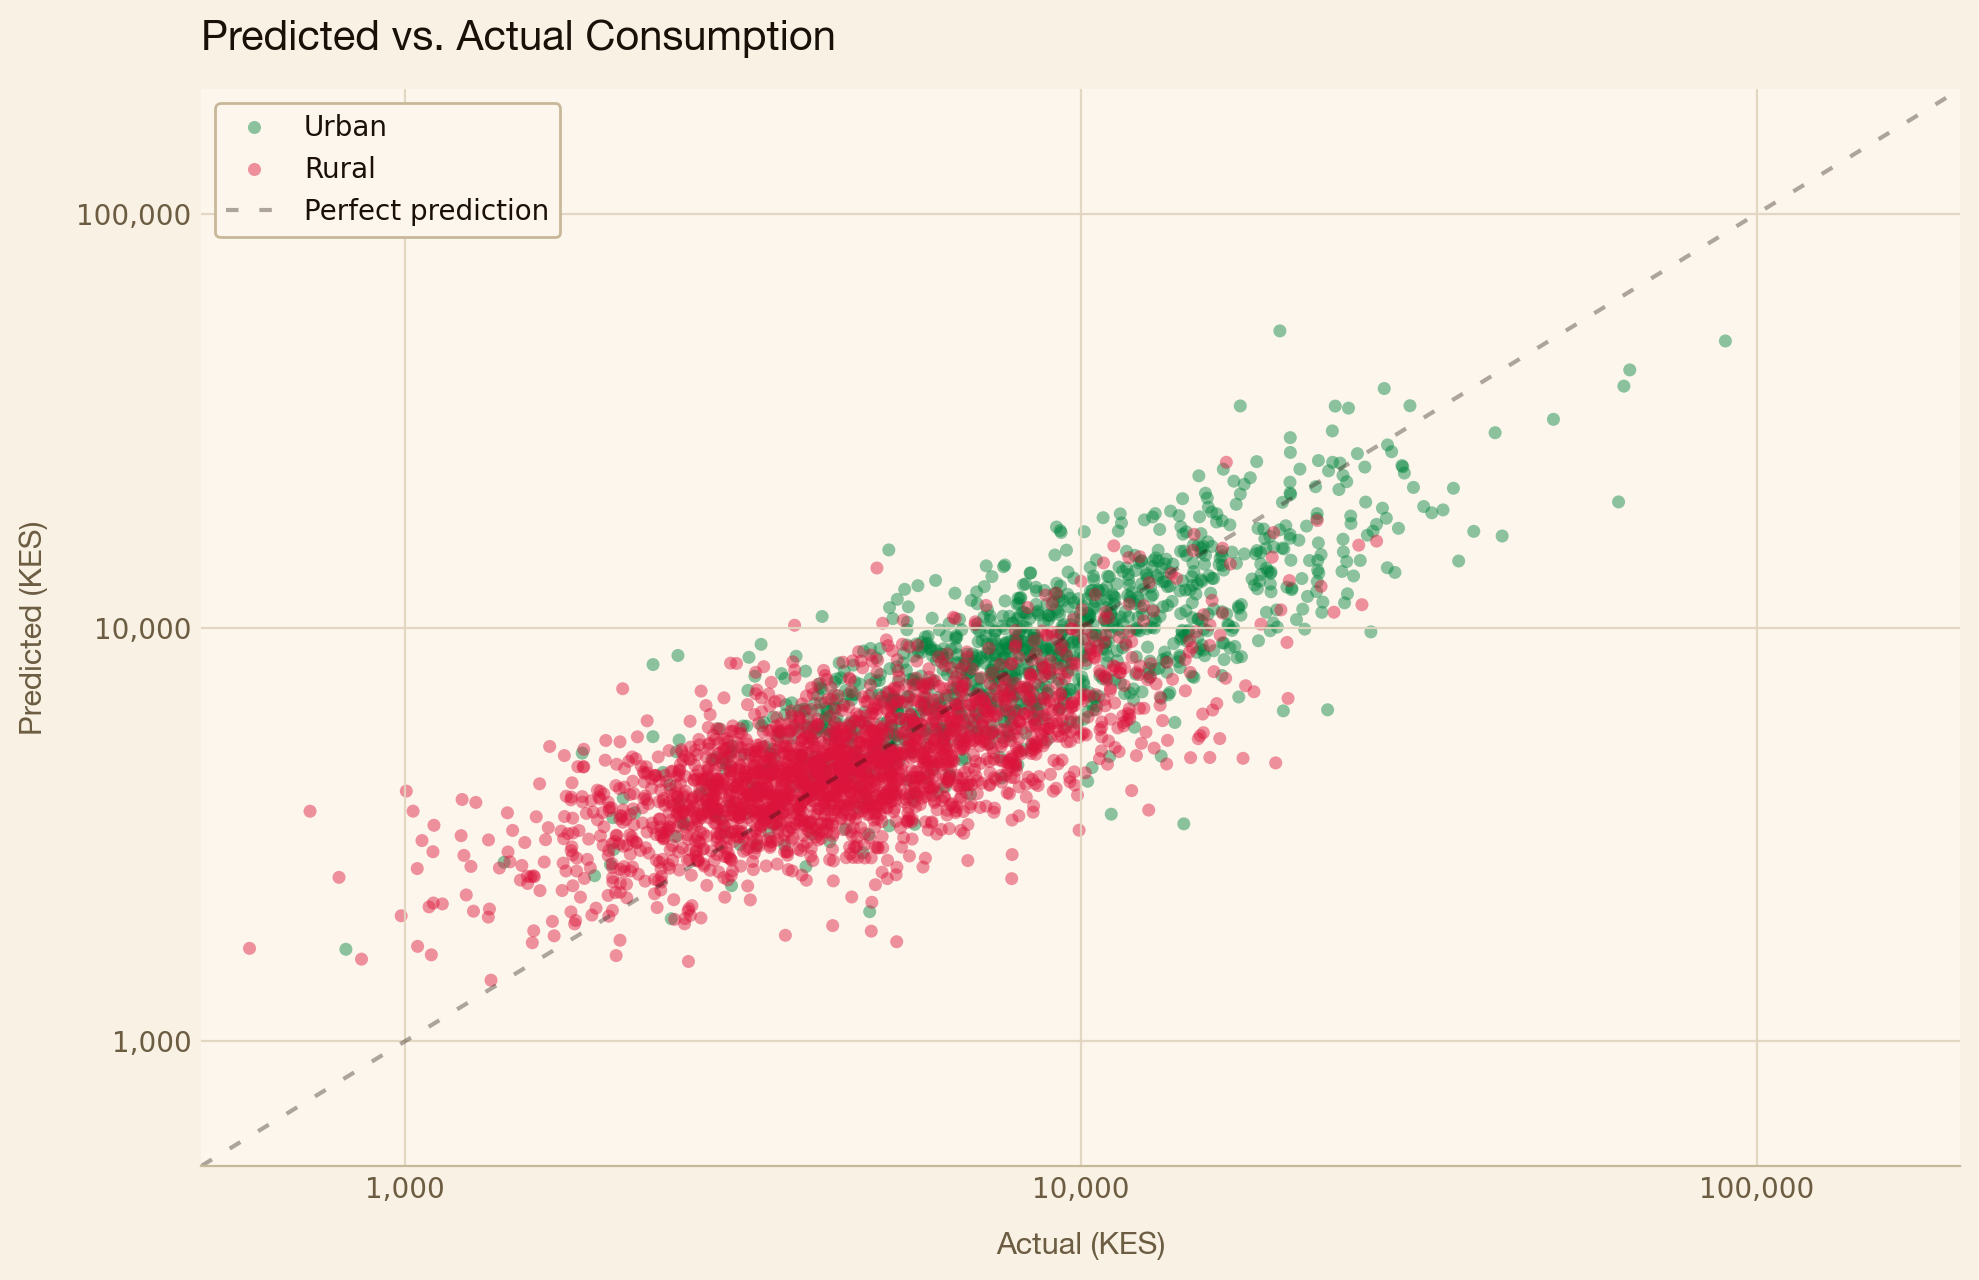

In [3]:
# Now run the scatter plot to see your changes
plot_prediction_scatter(validation_df, save_path=OUT_PATH / 'overall_prediction_scatter.png')

(<Figure size 2000x1300 with 1 Axes>,
 <Axes: title={'left': 'Comparing Actual vs. Predicted Consumption Distributions'}, xlabel='Log Consumption per Capita', ylabel='Density'>)

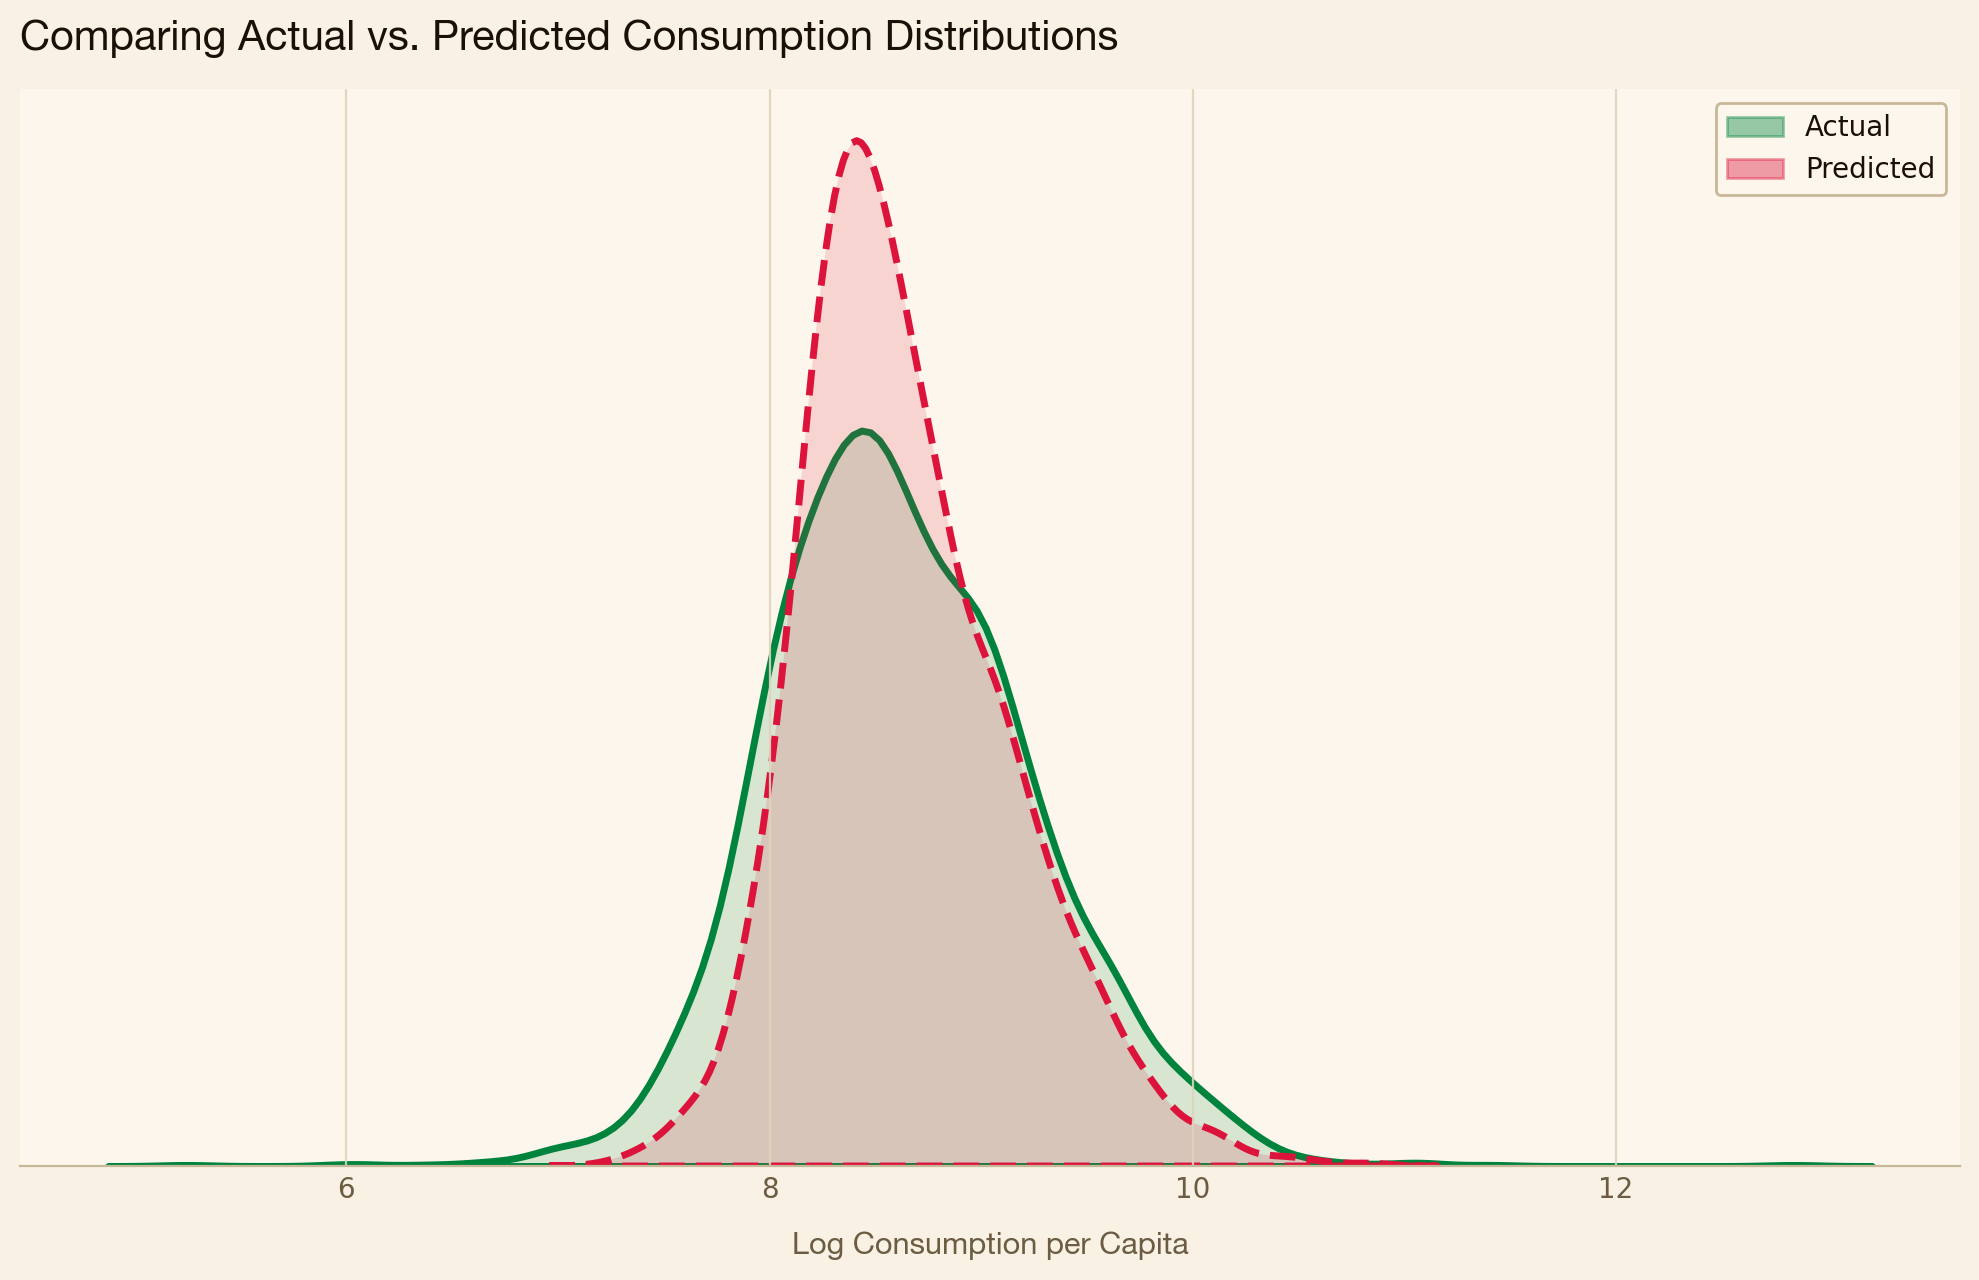

In [4]:
plot_density_comparison(validation_df, save_path=OUT_PATH / 'density_comparison.png')

#### Poverty Line Scatter Plots
Scatter plots with poverty line overlaid, showing exclusion and inclusion errors by quadrant. Inspired by Figure 1 in *A Poor Means Test*.

(<Figure size 2000x1600 with 1 Axes>,
 <Axes: title={'left': 'Exclusion Errors — Urban, Bottom 40%'}, xlabel='Actual Consumption (percentile)', ylabel='Predicted Consumption (percentile)'>)

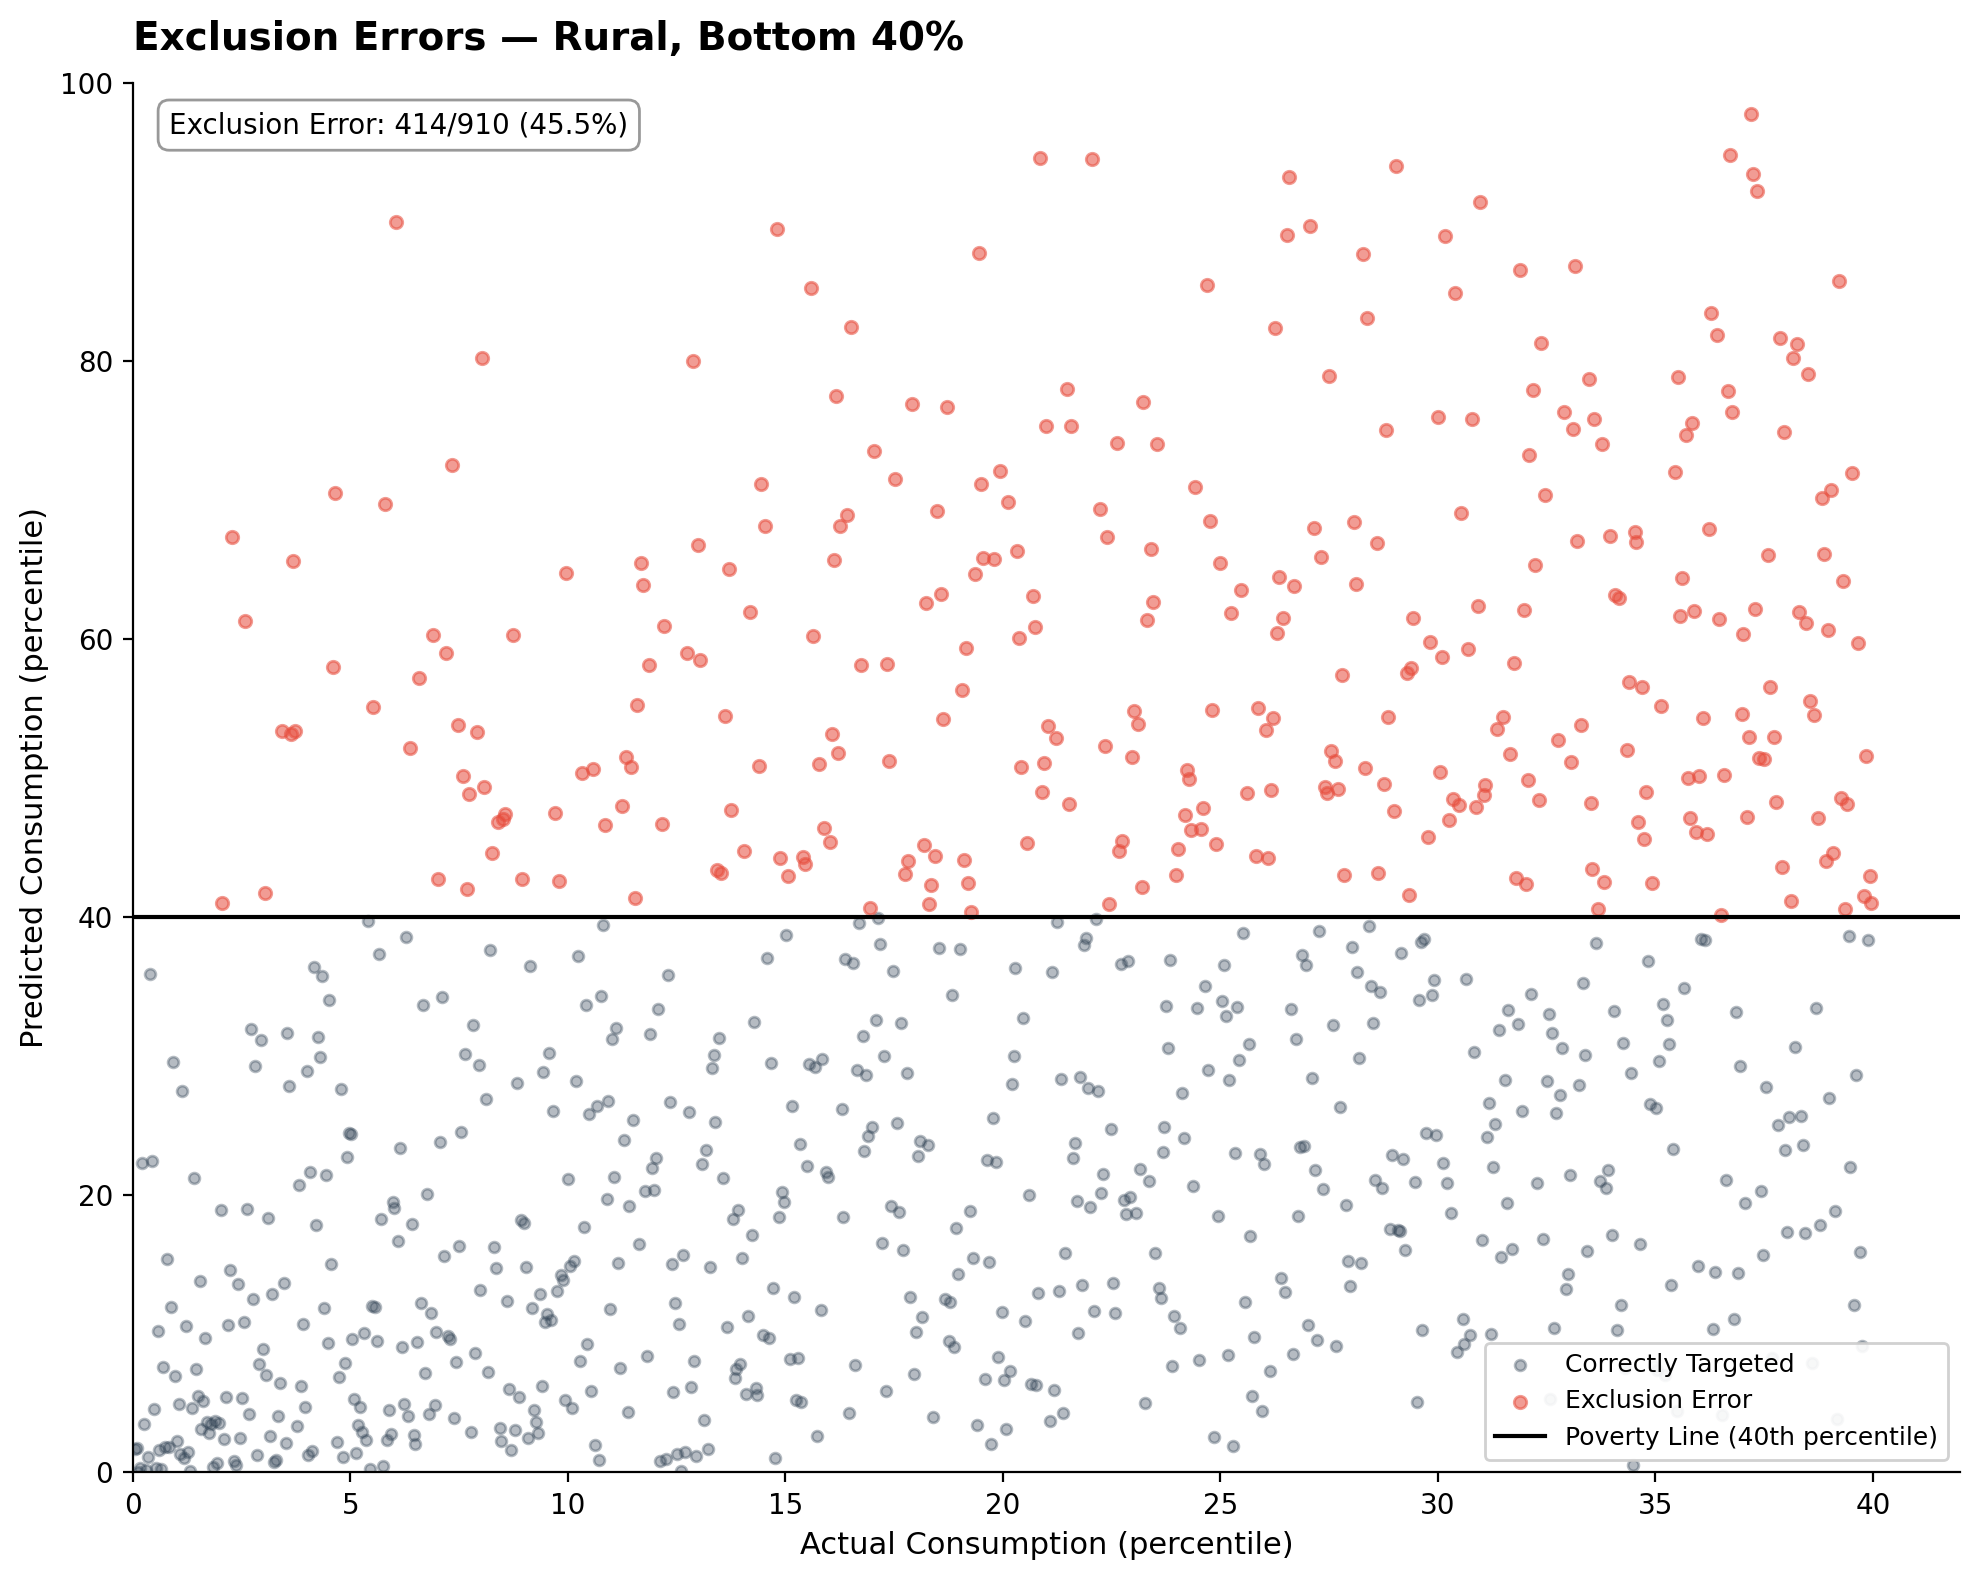

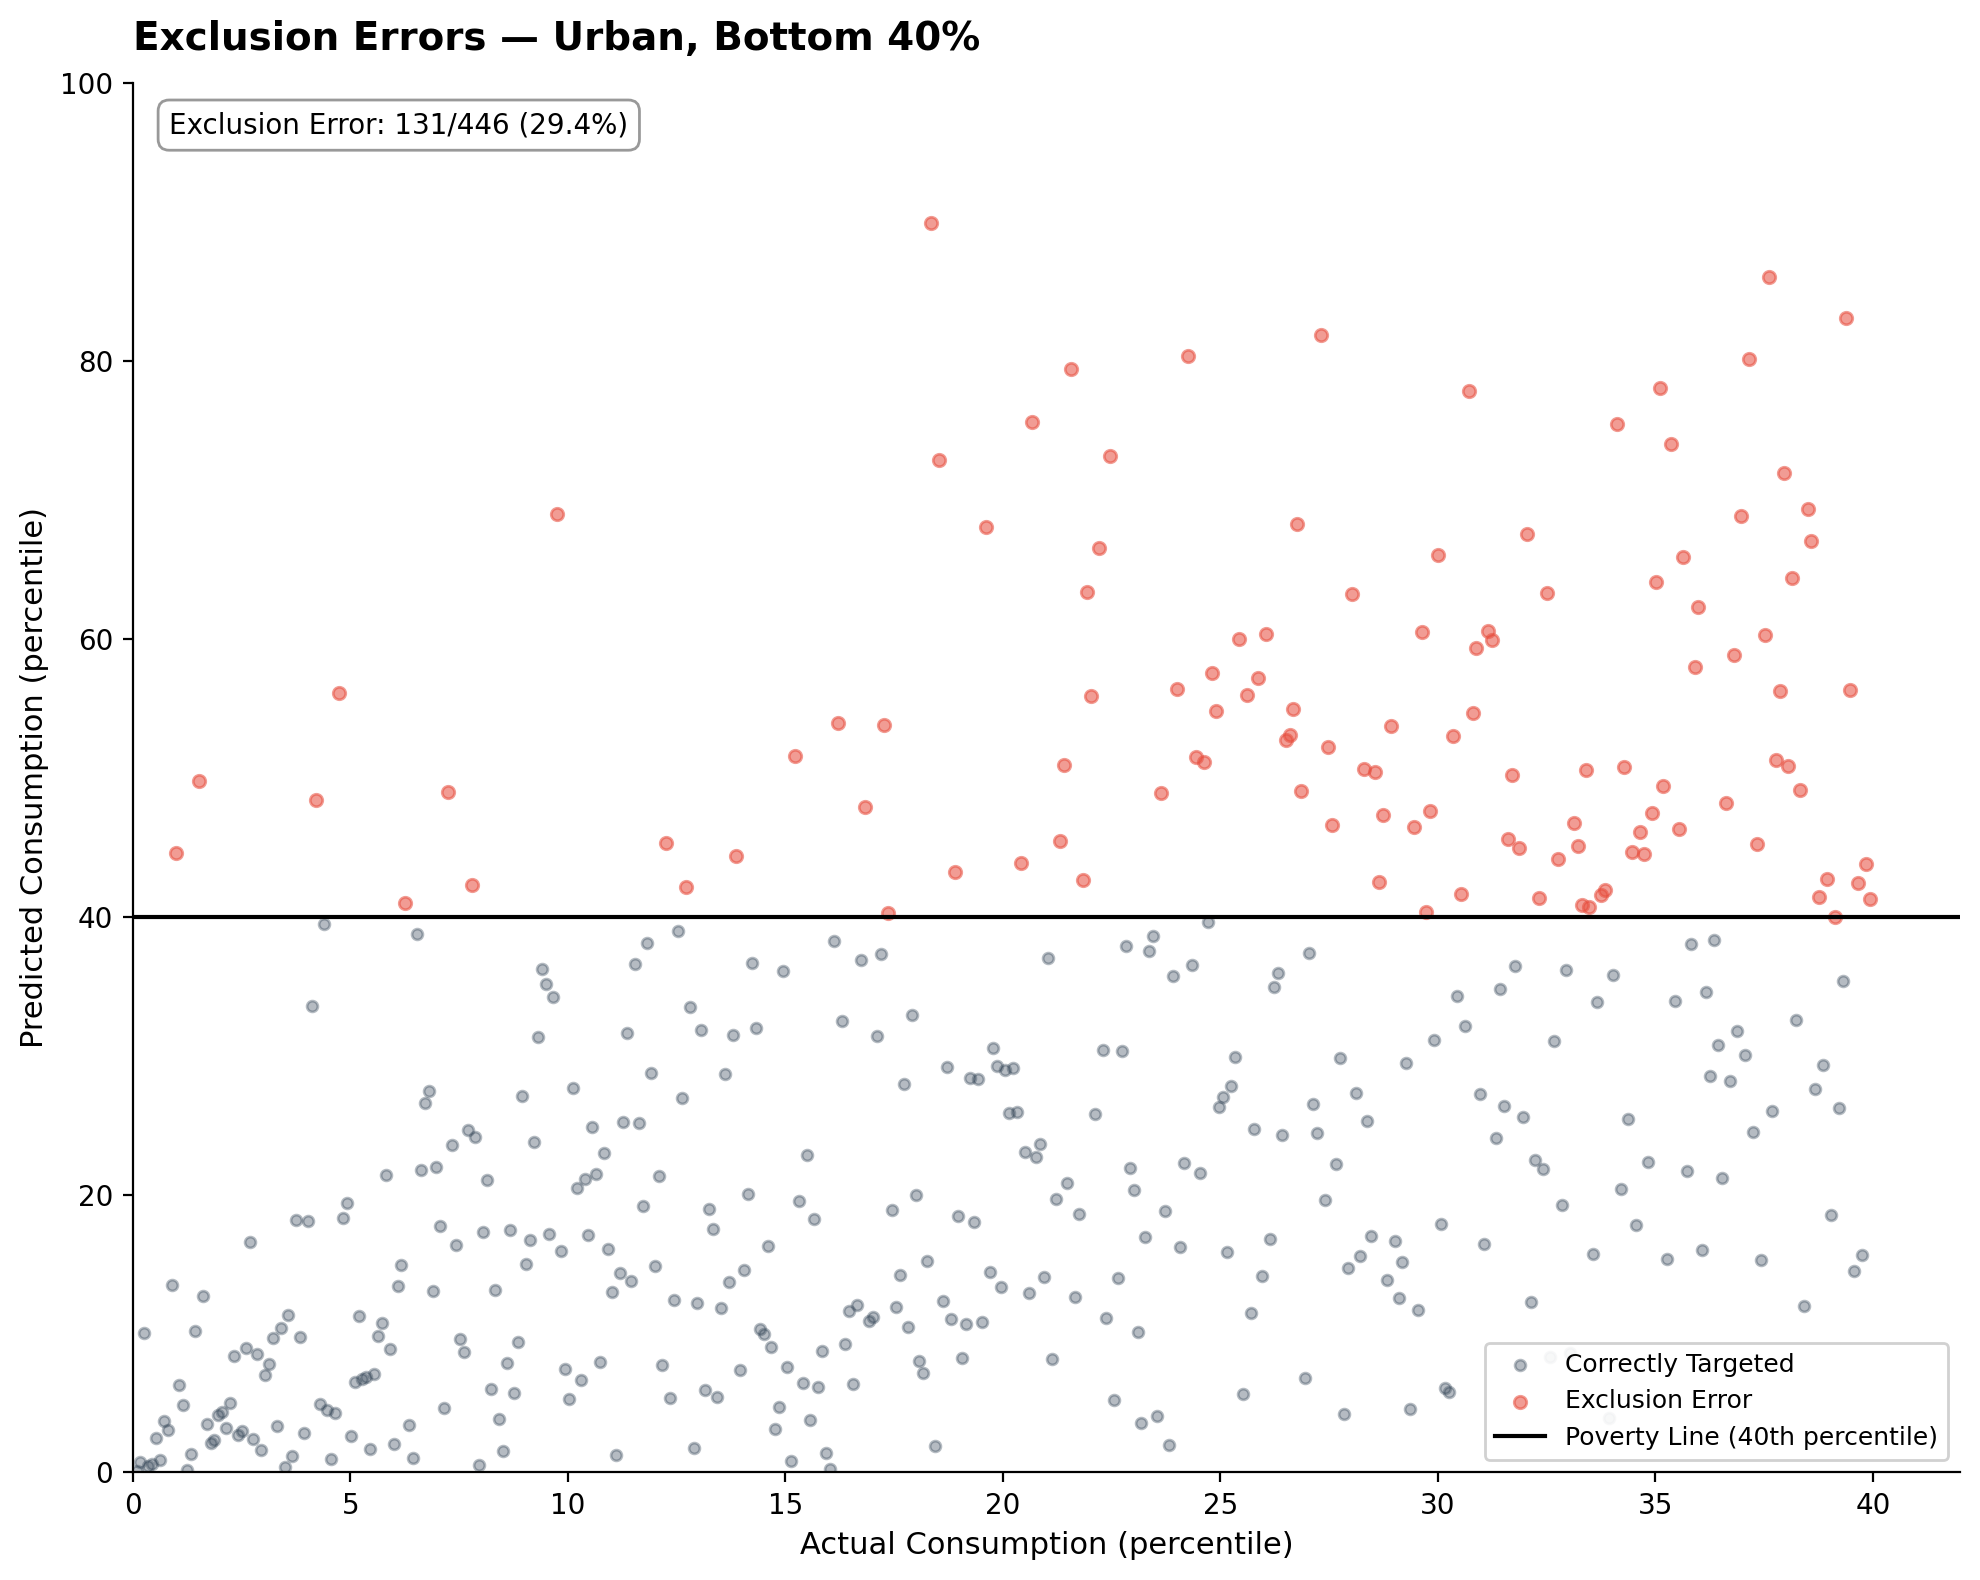

In [5]:
# Bottom 40% — Rural and Urban
rural_40 = validation_df[validation_df['urban_rural_classification'] == 'Rural']
urban_40 = validation_df[validation_df['urban_rural_classification'] == 'Urban']

plot_poverty_line_scatter(rural_40, quantile=0.40, title='Exclusion Errors — Rural, Bottom 40%',
                          save_path=OUT_PATH / 'poverty_scatter_rural_bottom40.png')
plot_poverty_line_scatter(urban_40, quantile=0.40, title='Exclusion Errors — Urban, Bottom 40%',
                          save_path=OUT_PATH / 'poverty_scatter_urban_bottom40.png')

(<Figure size 2000x1600 with 1 Axes>,
 <Axes: title={'left': 'Exclusion Errors — Urban, Bottom 25%'}, xlabel='Actual Consumption (percentile)', ylabel='Predicted Consumption (percentile)'>)

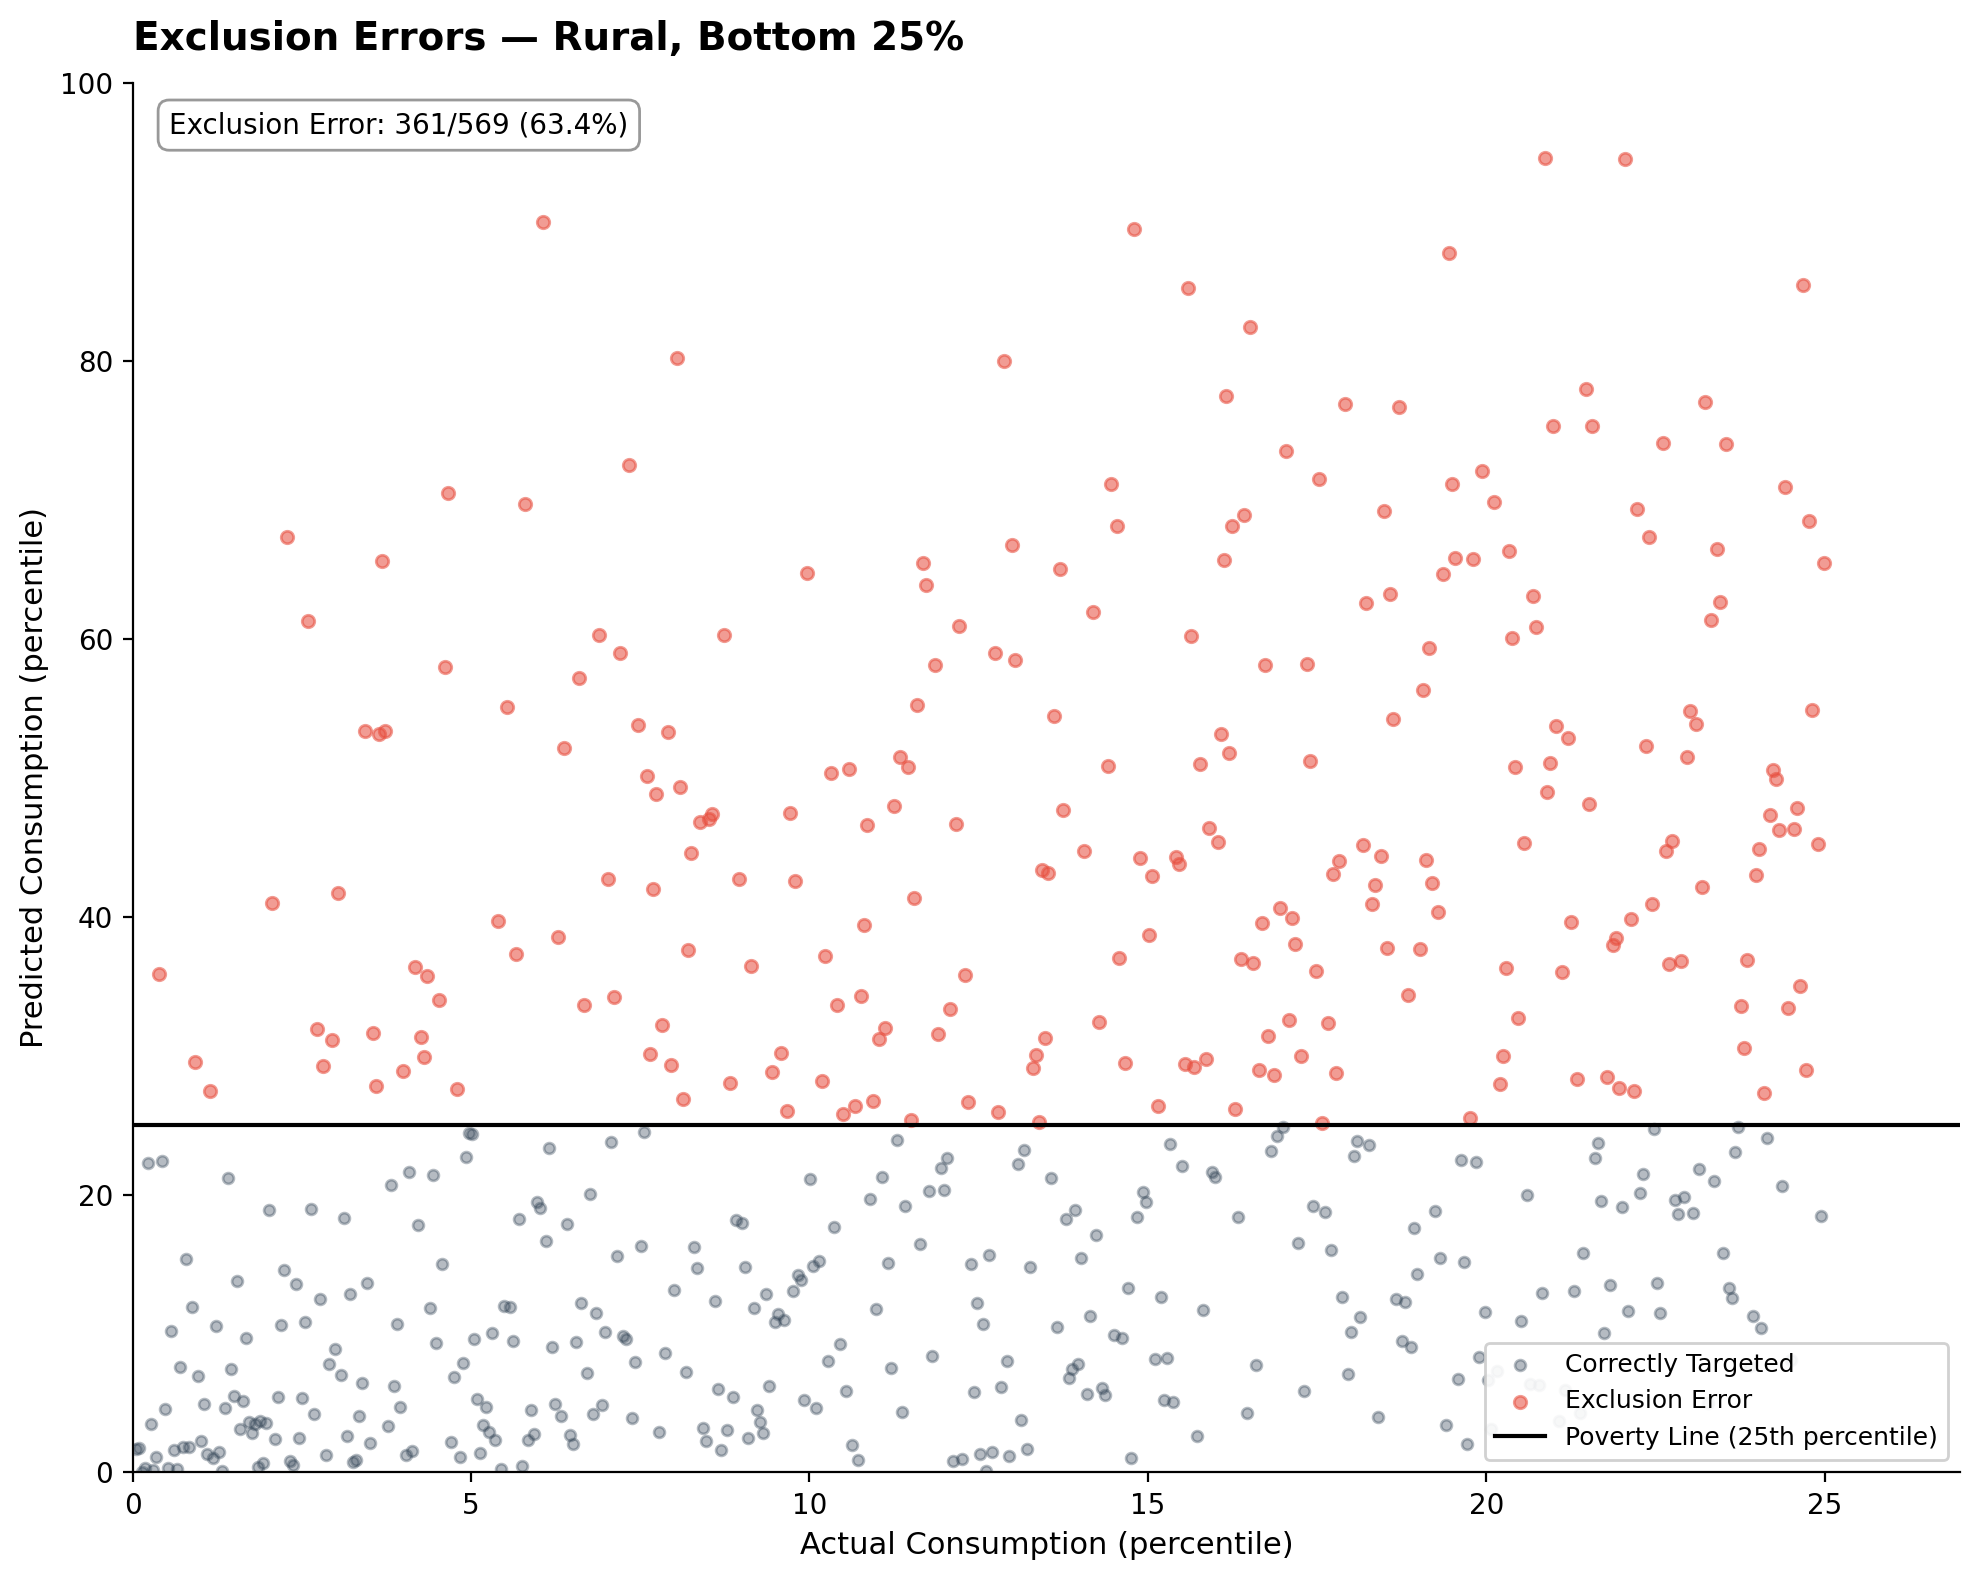

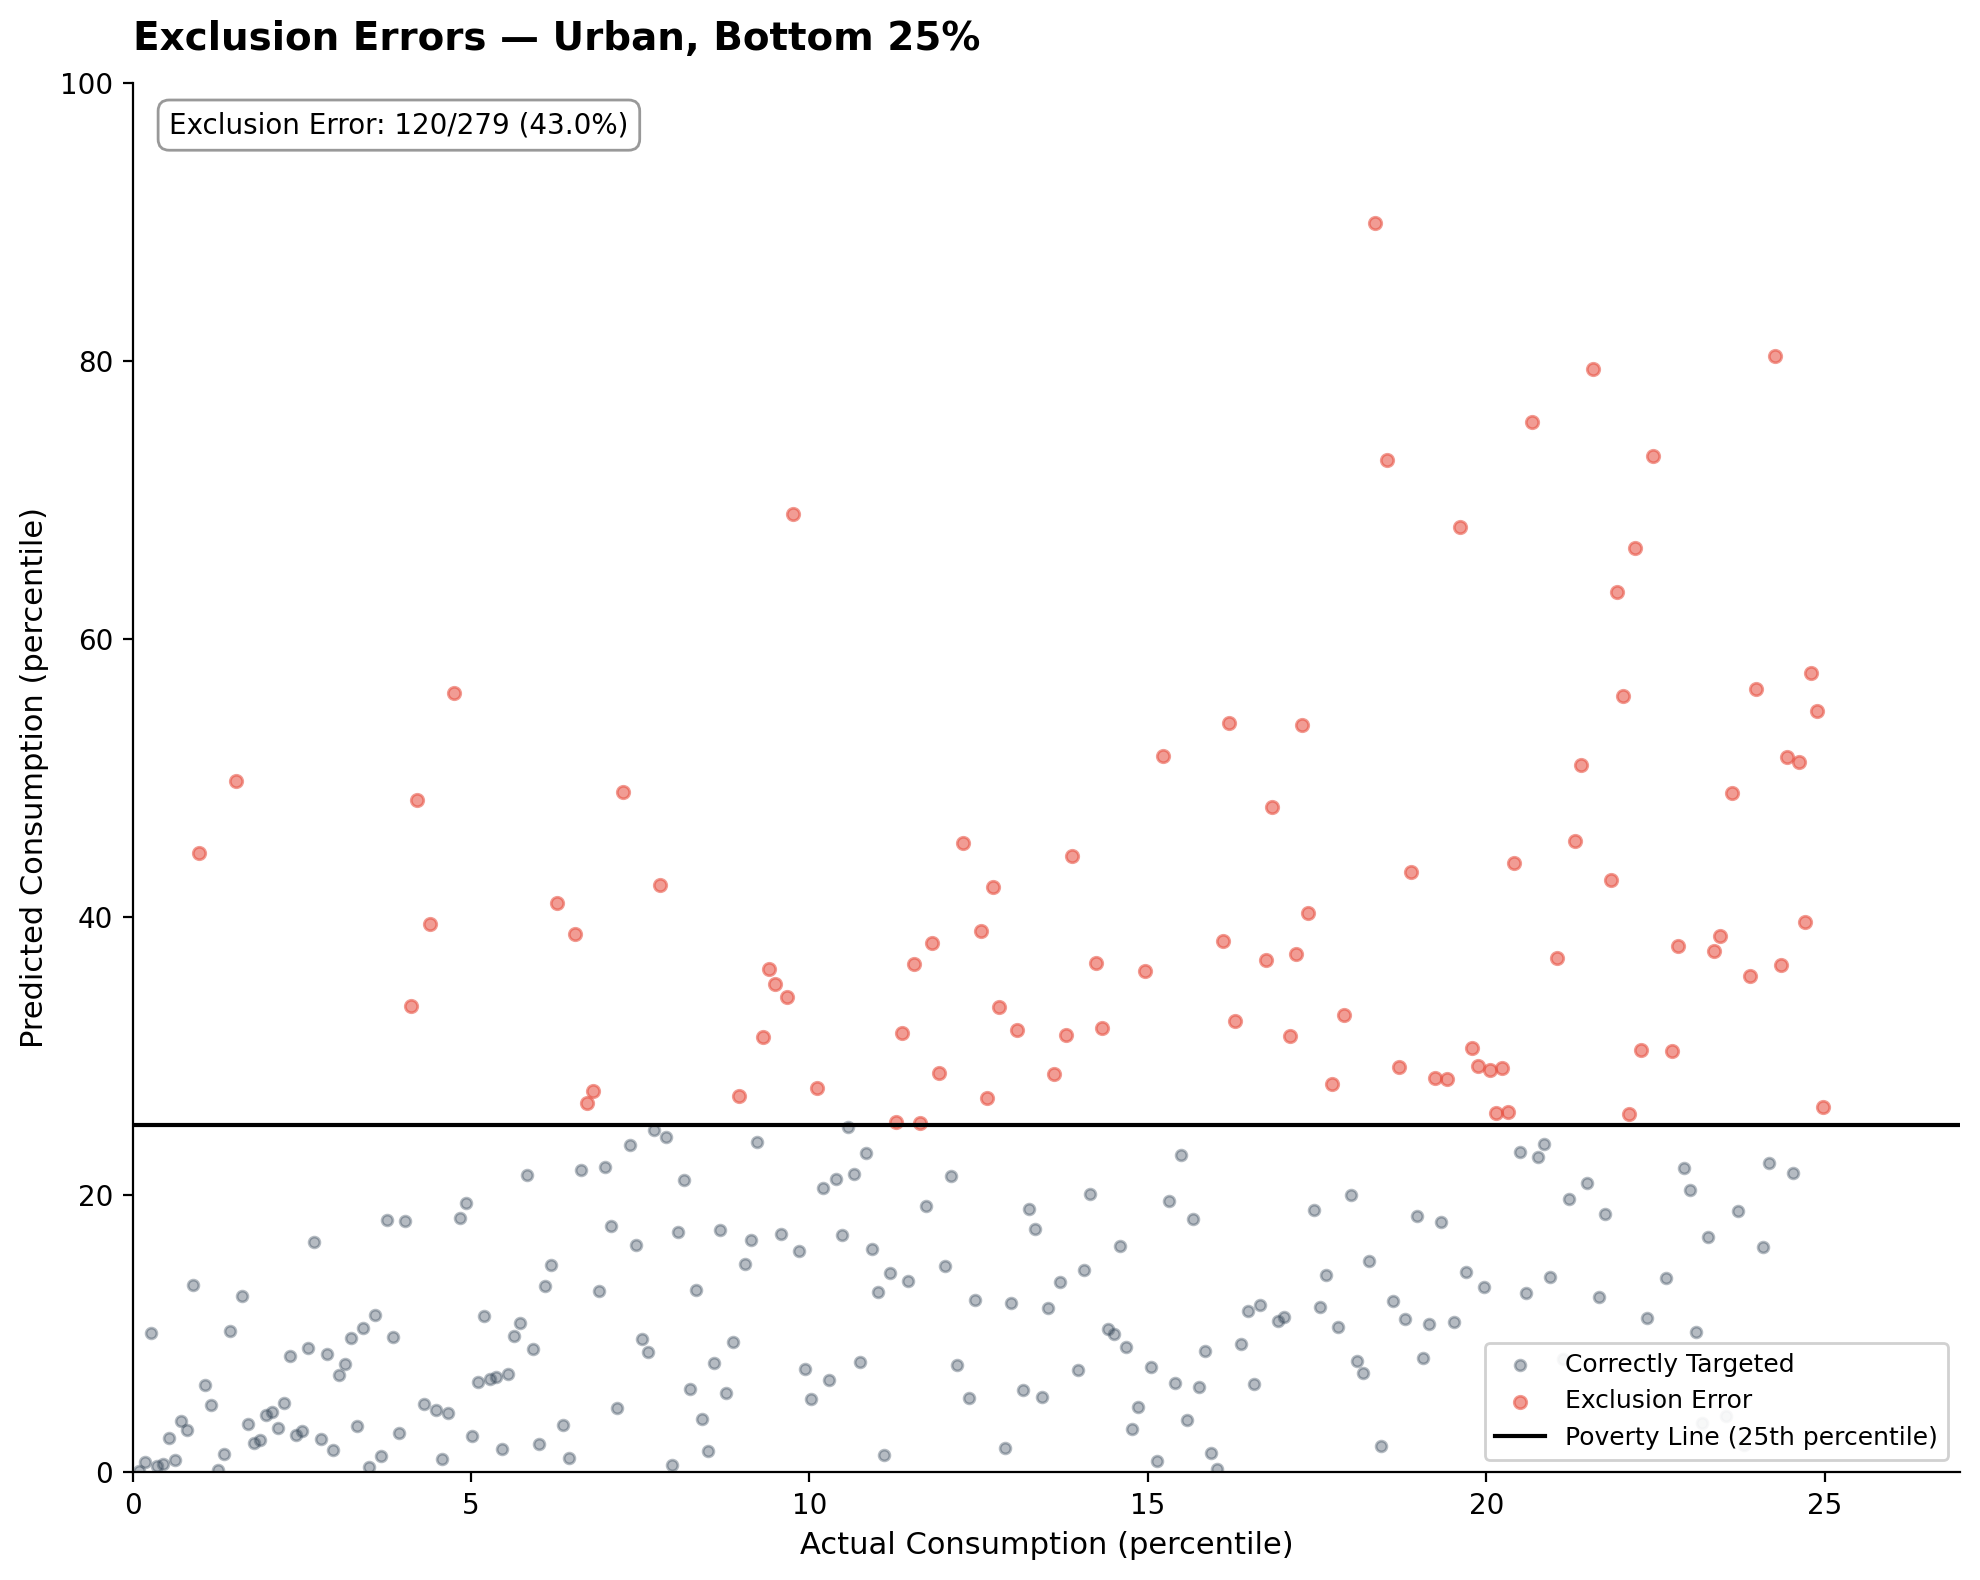

In [6]:
# Bottom 25% — Rural and Urban
plot_poverty_line_scatter(rural_40, quantile=0.25, title='Exclusion Errors — Rural, Bottom 25%',
                          save_path=OUT_PATH / 'poverty_scatter_rural_bottom25.png')
plot_poverty_line_scatter(urban_40, quantile=0.25, title='Exclusion Errors — Urban, Bottom 25%',
                          save_path=OUT_PATH / 'poverty_scatter_urban_bottom25.png')

## Splitting the categories

In [7]:
# Split into rural and urban 
urban_df = validation_df[validation_df['urban_rural_classification'] == 'Urban'].copy()
urban_df.attrs['name'] = 'Urban'

rural_df = validation_df[validation_df['urban_rural_classification'] == 'Rural'].copy()
rural_df.attrs['name'] = 'Rural'

# Split into absolute poor and not poor 
not_poor_df = validation_df[validation_df['abs_poor'] == 0].copy()
not_poor_df.attrs['name'] = 'Not Poor'

poor_df = validation_df[validation_df['abs_poor'] == 1].copy()
poor_df.attrs['name'] = 'Abs Poor'


# What is the overall accuracy of the model? Accuracy metrics using the validation DF

### 1. By how much is the model model's prediction 'off' for a typical household's expenditure

In [8]:
def calculate_r2_metrics(df : pd.DataFrame, category : str):
        # Calculate metrics
        rmse = np.sqrt(mean_squared_error(df['Actual'], df['Predicted']))
        r2 = r2_score(df['Actual'], df['Predicted'])
        
        # Print results
        print(f"\n--- {category} ---")
        print(f"Validation RMSE: {rmse:.4f}")
        print(f"Validation R-squared: {r2:.4f}")
        print("-" * 25)

calculate_r2_metrics(urban_df, 'Urban')
calculate_r2_metrics(rural_df, 'Rural')



--- Urban ---
Validation RMSE: 0.3598
Validation R-squared: 0.6285
-------------------------

--- Rural ---
Validation RMSE: 0.3868
Validation R-squared: 0.4513
-------------------------


(<Figure size 2400x1000 with 2 Axes>,
 array([<Axes: title={'center': 'Not Poor: Residual Plot'}, xlabel='Predicted', ylabel='Residuals'>,
        <Axes: title={'center': 'Abs Poor: Residual Plot'}, xlabel='Predicted', ylabel='Residuals'>],
       dtype=object))

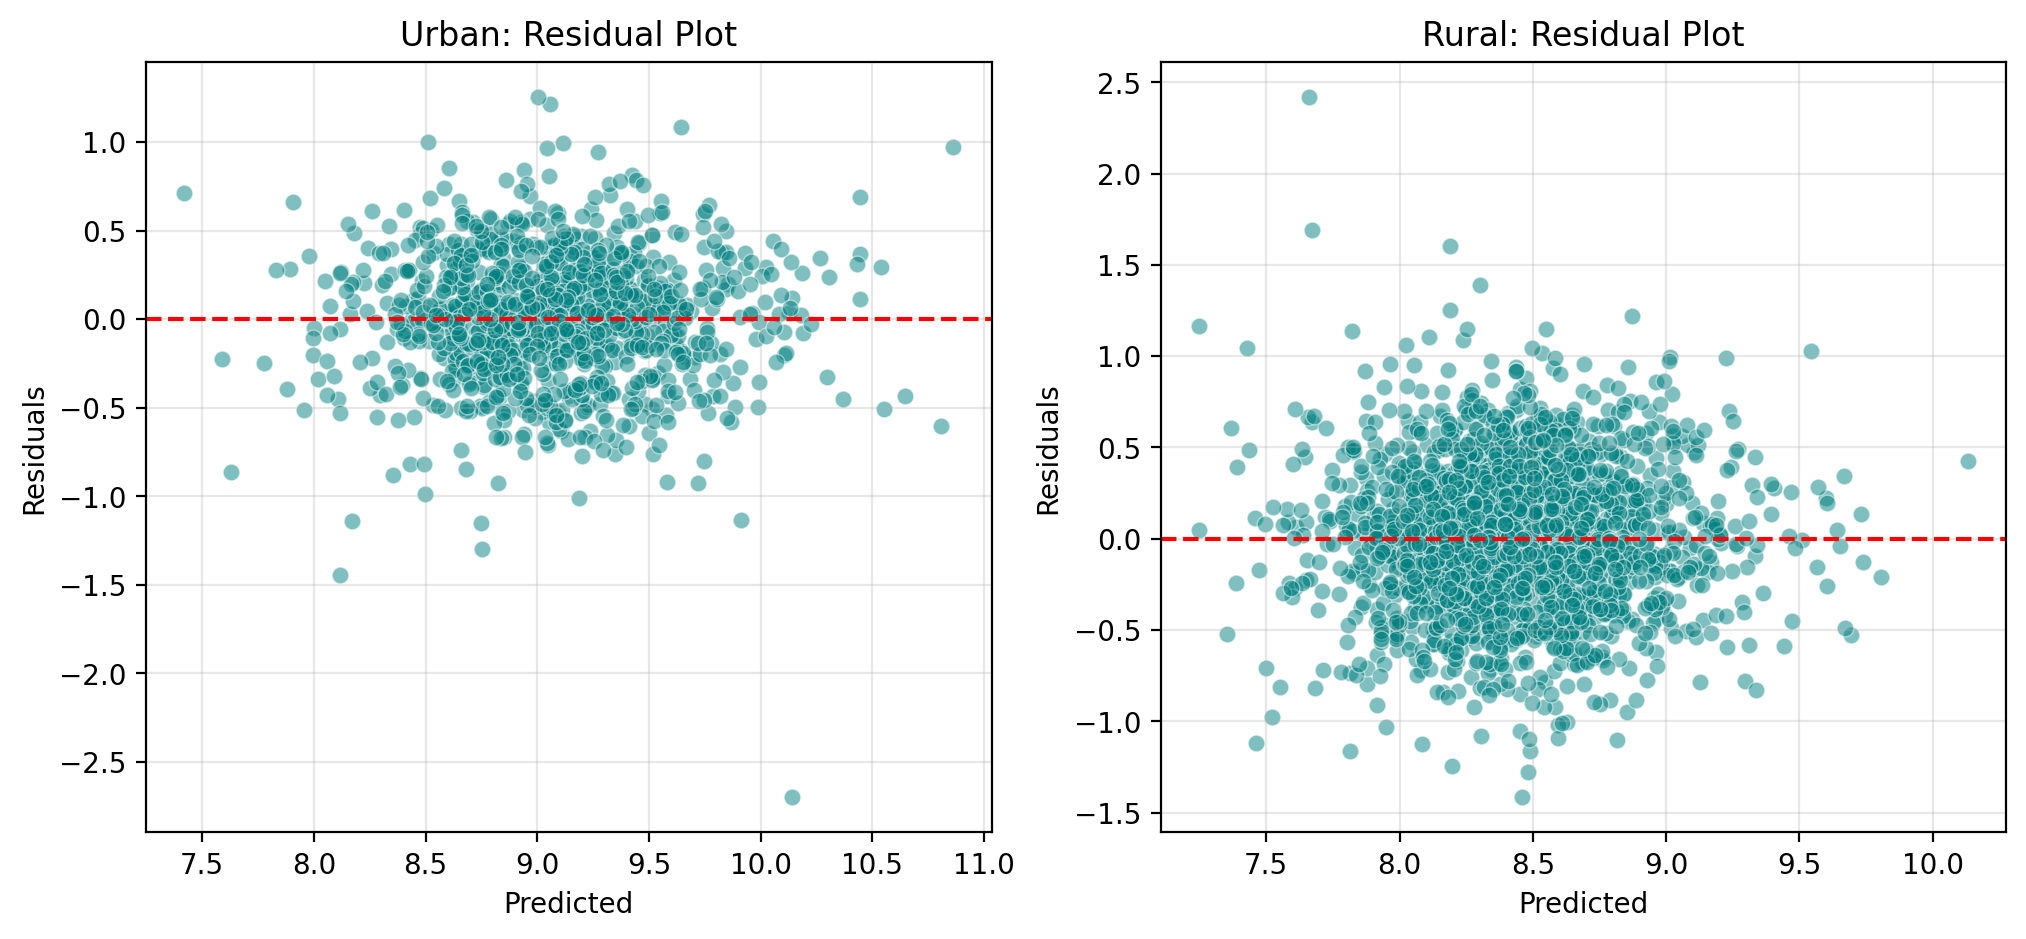

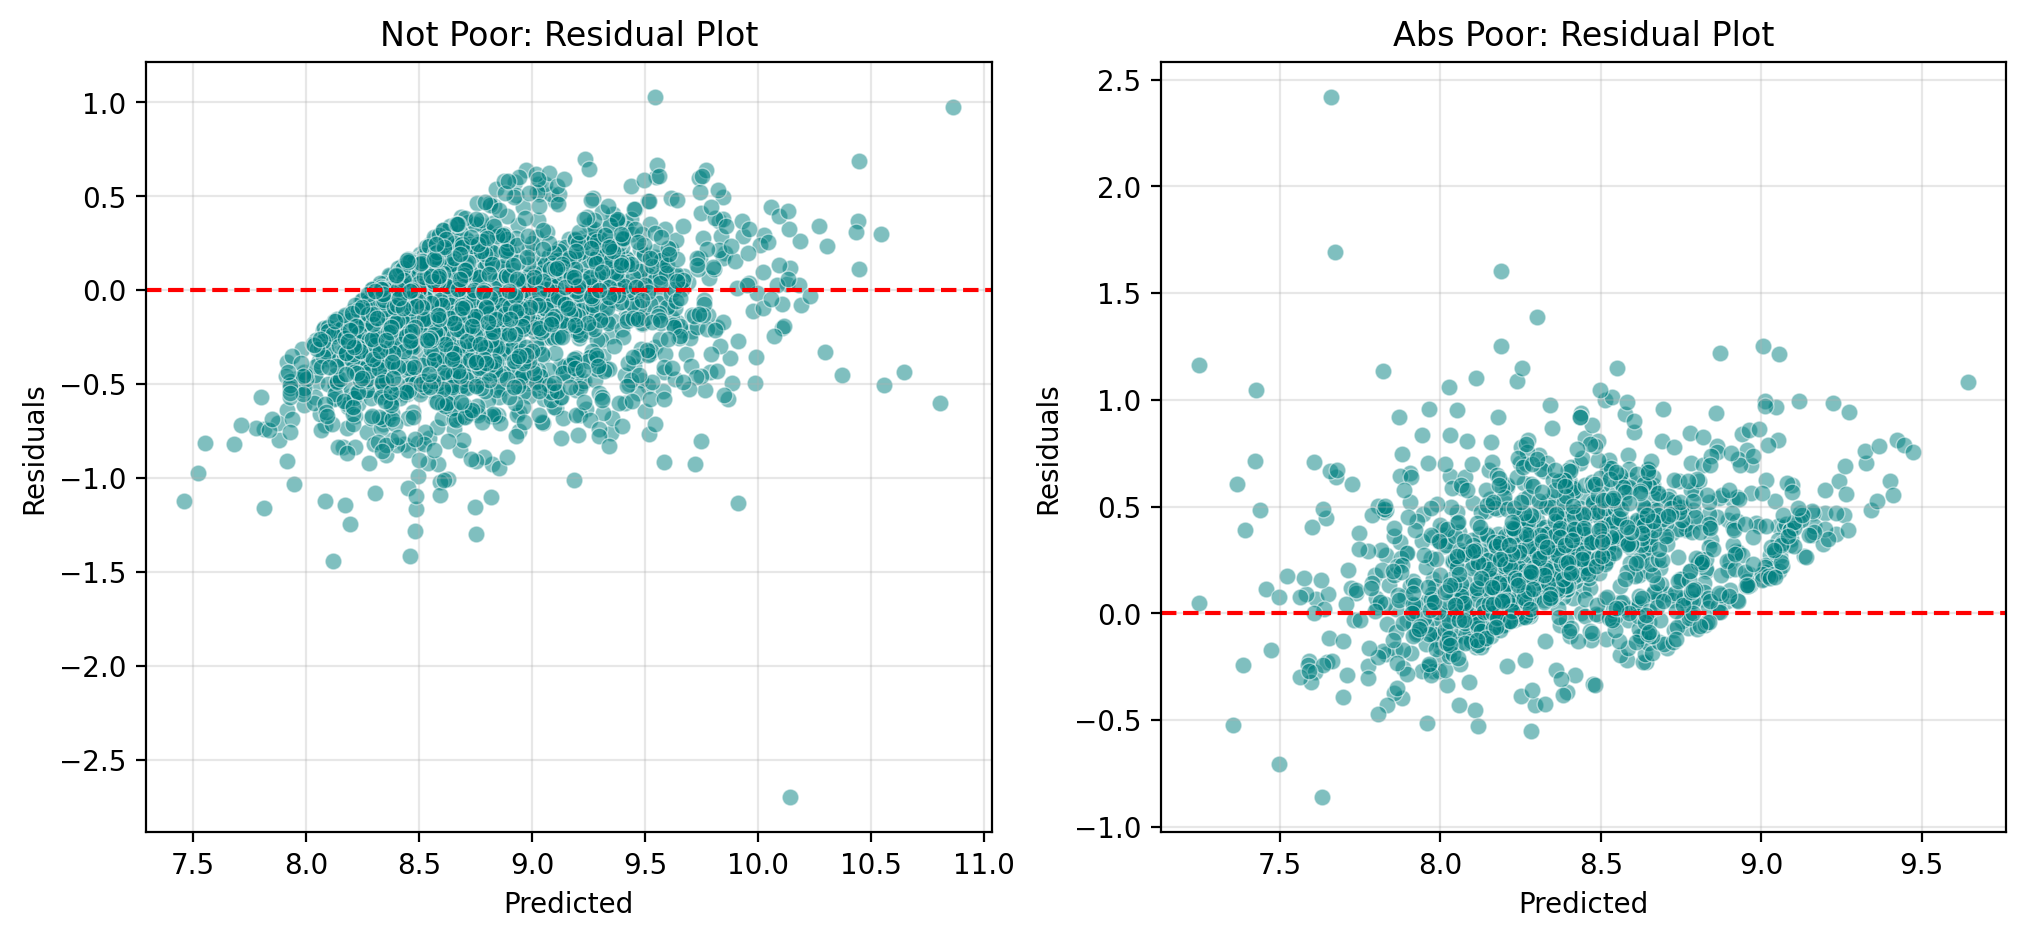

In [9]:
plot_residuals_grid([urban_df, rural_df], ['Urban', 'Rural'], save_path=OUT_PATH / 'sector_residuals.png')
plot_residuals_grid([not_poor_df, poor_df], ['Not Poor', 'Abs Poor'], save_path=OUT_PATH / 'abs_poor_residuals.png')

## Can this model effectively target the most vulnerable households?

#### Calculating the threshold for hidden poor . Rural Hardcore Poverty Line, is approximately KES 2,668 per person per month

#### To what extent is the model overcharging poor people at the expense of undercharging rich people. 
How effective is the model at reaching the bottom and top 20% of the population

In [10]:
def calculate_wealth_classification(df : pd.DataFrame) -> pd.DataFrame : 
    rich_line = df['Actual'].quantile(0.8)

    df['Actually_Rich'] = df['Actual'] >= rich_line
    df['Predicted_Rich'] = df['Predicted'] >= rich_line

    return df 

# Create wealth classifications for urban and rural 
urban_df = calculate_wealth_classification(urban_df)
rural_df = calculate_wealth_classification(rural_df)

# Create a national version 
all_df = pd.concat([urban_df, rural_df]).copy()
all_df.attrs['name'] = 'All'


In [11]:
def calculate_pmt_metrics(df):
    
    # Calculate Headcounts
    actual_poor_count = int(df['Actually_Poor'].sum())
    pred_poor_count = int(df['Predicted_Poor'].sum())
    
    # Calculate Accuracy Metrics
    excl = (df[(df['Actually_Poor'] == True) & (df['Predicted_Poor'] == False)].shape[0] / actual_poor_count) * 100
    incl = (df[(df['Actually_Poor'] == False) & (df['Predicted_Poor'] == True)].shape[0] / pred_poor_count) * 100 if pred_poor_count > 0 else 0
    bal_acc = balanced_accuracy_score(df['Actually_Poor'], df['Predicted_Poor'])
    rank_corr, _ = spearmanr(df['Actual'], df['Predicted'])
    mape = (np.abs((df['Actual_KES'] - df['Predicted_KES']) / df['Actual_KES'])).mean() * 100

    poor = df[df['Actually_Poor'] == True]
    mape_poor = (np.abs((poor['Actual_KES'] - poor['Predicted_KES']) / poor['Actual_KES'])).mean() * 100
    
    return {
        'Level': df.attrs.get('name'),
        'Actual Poor': actual_poor_count,
        'Predicted Poor': pred_poor_count,
        'Exclusion (%)': round(excl, 2),
        'Inclusion (%)': round(incl, 2),
        'Balanced Acc': round(bal_acc, 3),
        'Rank Corr': round(rank_corr, 3),
        'MAPE (%)': round(mape, 2),
        'MAPE Poor (%)': round(mape_poor, 2)
    }

In [12]:
results = [calculate_pmt_metrics(urban_df),
           calculate_pmt_metrics(rural_df),
           calculate_pmt_metrics(all_df)
]

report_df = pd.DataFrame(results)

print(f"\n{'='*35}  PMT PERFORMANCE SUMMARY {'='*35}")
display(report_df)

report_df.to_csv(OUT_PATH / 'model_performance_summary.csv', index=False)


===================================  PMT PERFORMANCE SUMMARY ===================================


,Level,Actual Poor,Predicted Poor,Exclusion (%),Inclusion (%),Balanced Acc,Rank Corr,MAPE (%),MAPE Poor (%)
0,Urban,414,393,29.71,25.95,0.779,0.780,28.67,36.83
1,Rural,929,762,43.06,30.58,0.698,0.633,32.65,44.47
2,All,1343,1155,38.94,29.00,0.724,0.770,31.34,42.12


#### Prediction accuracy chart 

This chart examines all income deciles and evaluates prediction accuracy. A household’s predicted wealth is considered ‘accurate’ if it falls within ±20% of its actual wealth.

Actual and predicted wealth is logged to create more comparable relative errors. 

(<Figure size 2250x1200 with 1 Axes>,
 <Axes: title={'center': 'Prediction Accuracy (±20.0%)'}, xlabel='Actual Income Decile (1 = lowest)', ylabel='Percentage of Population (%)'>)

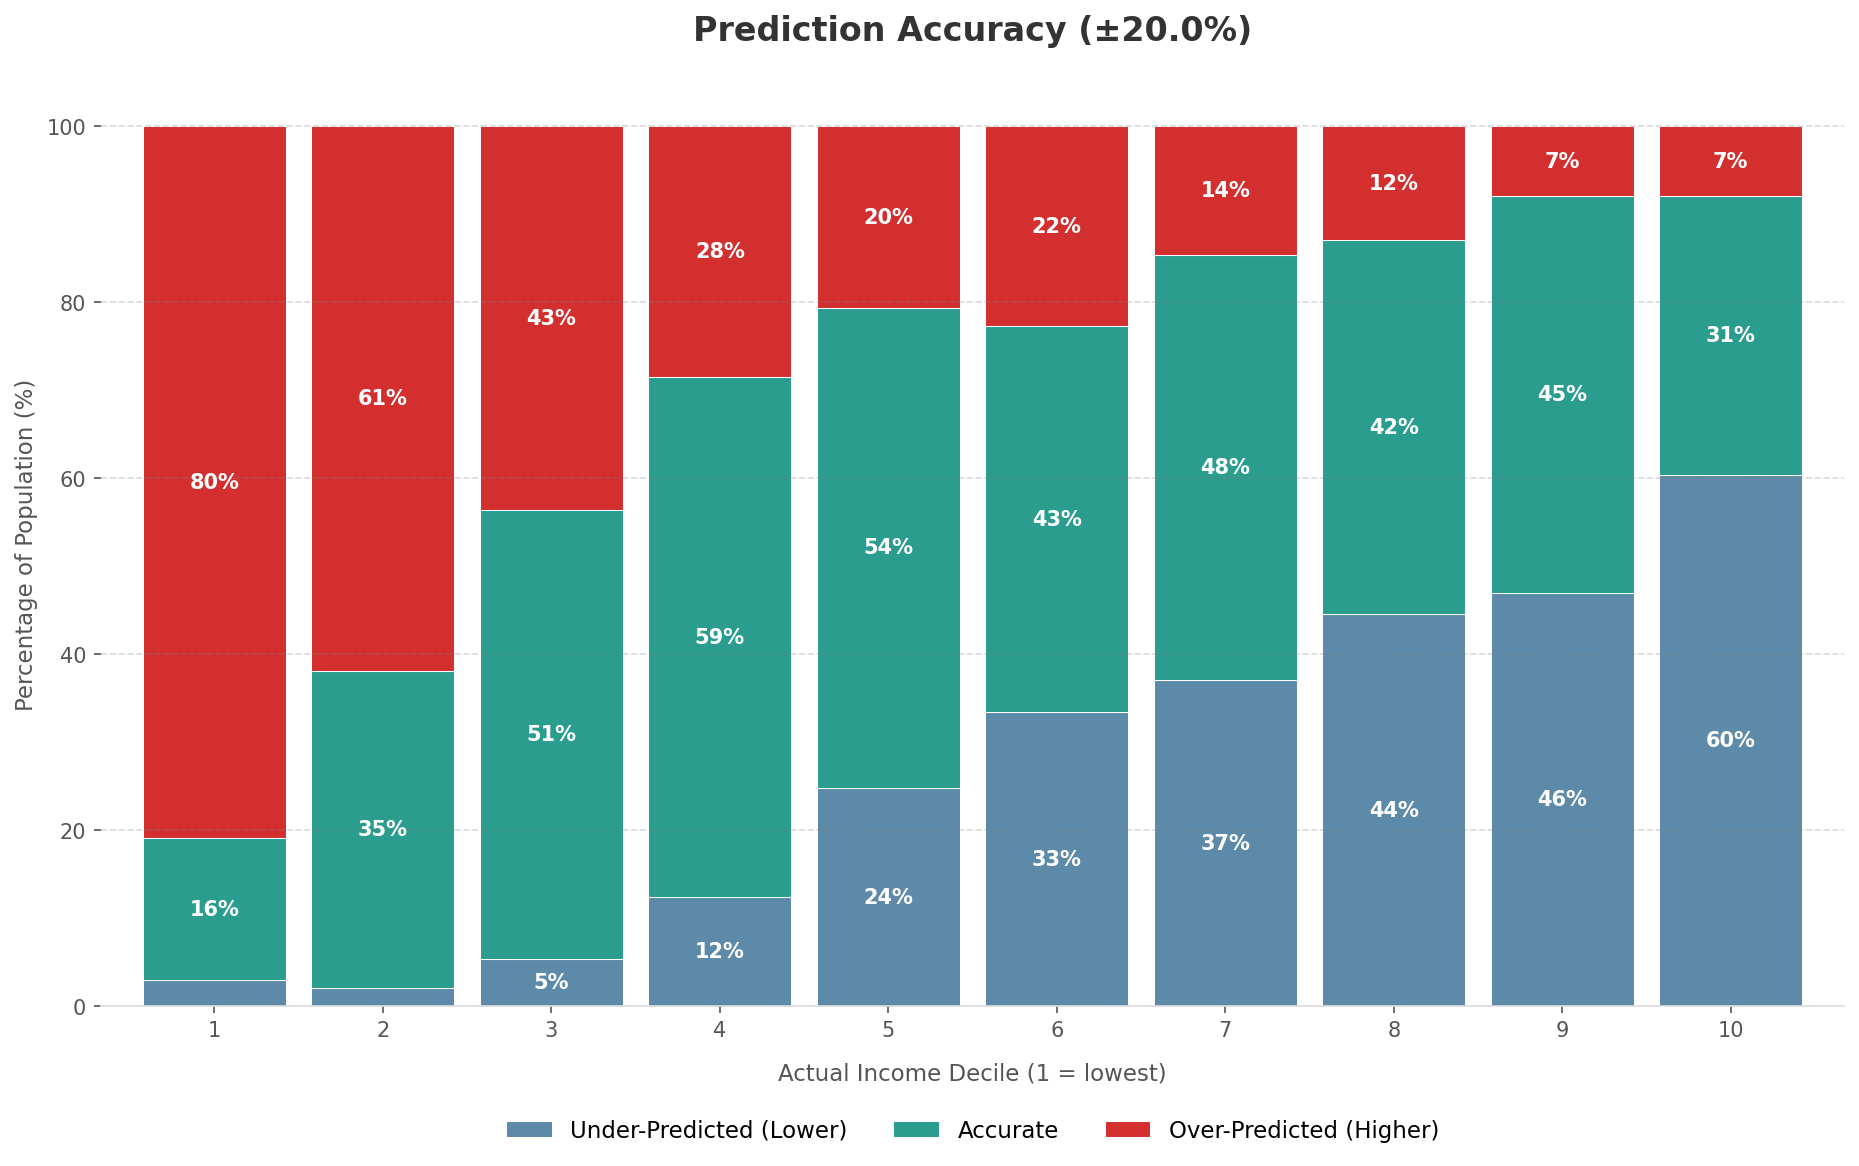

In [13]:
# Get Log error 
validation_df['log_error'] = validation_df['Predicted'] - validation_df['Actual']
validation_df['pct_log_error'] = 100 * (np.log(validation_df['Predicted']) - np.log(validation_df['Actual']))

# Get actual income and edges
validation_df['Actual_Decile'] = pd.qcut(validation_df['Actual_KES'], 10, labels=False) + 1
decile_edges = pd.qcut(validation_df['Actual_KES'], 10, retbins=True)[1]

# Get the predicted  
validation_df['Predicted_Decile'] = np.digitize(validation_df['Predicted_KES'], decile_edges)

# Calculate the difference 
validation_df['Decile_Diff'] = validation_df['Predicted_Decile'] - validation_df['Actual_Decile']

prediction_bar_chart(validation_df, log = True, tolerance=0.2, save_path=OUT_PATH)

In [14]:
def create_classification_report(
        df : pd.DataFrame, 
        label_col : str = 'Actually_Poor', 
        pred_col : str = 'Predicted_Poor', 
        target_names : list = ['Non-Poor', 'Poor']
        ) -> pd.DataFrame : 

    class_report = classification_report(df[label_col], df[pred_col], target_names=target_names, output_dict=True)
    report_df = pd.DataFrame(class_report).transpose()

    return report_df 

# Urban Classification Report 
print("\nUrban Classification Report\n")
urban_class = create_classification_report(urban_df)
display(urban_class)

print("\nRural Classification Report\n")
rural_class = create_classification_report(rural_df)
display(rural_class)

print("\nPoor Classification Report (All)\n")
poor_class = create_classification_report(all_df)
display(poor_class)

print("\nRich Classification Report (All)\n")
rich_class = create_classification_report(all_df, label_col = 'Actually_Rich', pred_col = 'Predicted_Rich', target_names=['Non-Rich', 'Rich'])
display(rich_class)


Urban Classification Report



,precision,recall,f1-score,support
Non-Poor,0.830110,0.854908,0.842327,703.000000
Poor,0.740458,0.702899,0.721190,414.000000
accuracy,0.798568,0.798568,0.798568,0.798568
macro avg,0.785284,0.778903,0.781758,1117.000000
weighted avg,0.796882,0.798568,0.797429,1117.000000



Rural Classification Report



,precision,recall,f1-score,support
Non-Poor,0.735974,0.827151,0.778903,1348.000000
Poor,0.694226,0.569429,0.625665,929.000000
accuracy,0.722003,0.722003,0.722003,0.722003
macro avg,0.715100,0.698290,0.702284,2277.000000
weighted avg,0.718941,0.722003,0.716383,2277.000000



Poor Classification Report (All)



,precision,recall,f1-score,support
Non-Poor,0.766414,0.836665,0.800000,2051.000000
Poor,0.709957,0.610573,0.656525,1343.000000
accuracy,0.747201,0.747201,0.747201,0.747201
macro avg,0.738185,0.723619,0.728263,3394.000000
weighted avg,0.744074,0.747201,0.743227,3394.000000



Rich Classification Report (All)



,precision,recall,f1-score,support
Non-Rich,0.871424,0.953943,0.910818,2714.000000
Rich,0.704492,0.438235,0.540345,680.000000
accuracy,0.850619,0.850619,0.850619,0.850619
macro avg,0.787958,0.696089,0.725581,3394.000000
weighted avg,0.837978,0.850619,0.836592,3394.000000


#### Export as Excel 

In [15]:
with pd.ExcelWriter(OUT_PATH / 'classification_reports.xlsx', engine="openpyxl") as writer:
    urban_class.to_excel(writer, sheet_name="Urban_Poor")
    rural_class.to_excel(writer, sheet_name="Rural_Poor")
    poor_class.to_excel(writer, sheet_name="All_Poor")
    rich_class.to_excel(writer, sheet_name="All_Rich")

## Confusion matrix

In [16]:
datasets = {'Urban': urban_df, 'Rural': rural_df}
cm_frames = []

for label, df in datasets.items():
    cm = confusion_matrix(df['Actually_Poor'], df['Predicted_Poor'])
    cm_df = pd.DataFrame(cm, index=['Actually Not Poor', 'Actually Poor'], columns=['Predicted Not Poor', 'Predicted Poor'])
    cm_df['Total'] = cm_df.sum(axis=1)
    cm_df.loc['Total'] = cm_df.sum(axis=0)
    cm_df.index.name = label
    print(f"\n{label} Confusion Matrix")
    display(cm_df)
    cm_df_out = cm_df.copy()
    cm_df_out['Sector'] = label
    cm_frames.append(cm_df_out)

cm_all = pd.concat(cm_frames)
cm_all.to_csv(OUT_PATH / 'confusion_matrices.csv')


Urban Confusion Matrix


,Predicted Not Poor,Predicted Poor,Total
Urban,,,
Actually Not Poor,601,102,703
Actually Poor,123,291,414
Total,724,393,1117



Rural Confusion Matrix


,Predicted Not Poor,Predicted Poor,Total
Rural,,,
Actually Not Poor,1115,233,1348
Actually Poor,400,529,929
Total,1515,762,2277
